# Percentile Method

- In this Method outliers are detected and upper threshold and lower threshold is set and then outliers are replaced with threshold value in data.

- If we do Capping when using Percentile method then it is Called Winsorization.

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('../../DATASETS/weight-height.csv')

In [6]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [9]:
df.shape

(10000, 3)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  str    
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), str(1)
memory usage: 234.5 KB


In [10]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


C:\Users\admin\AppData\Local\Temp\ipykernel_10972\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

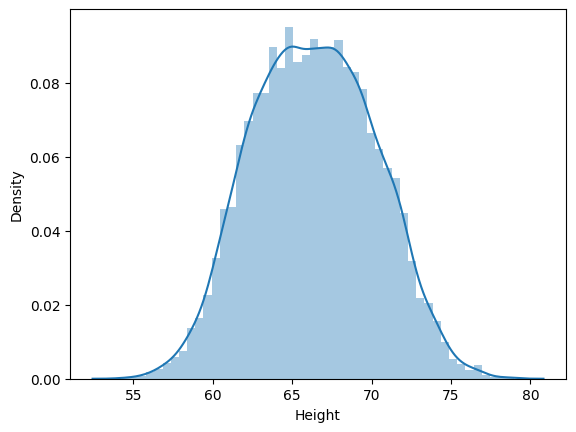

In [11]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

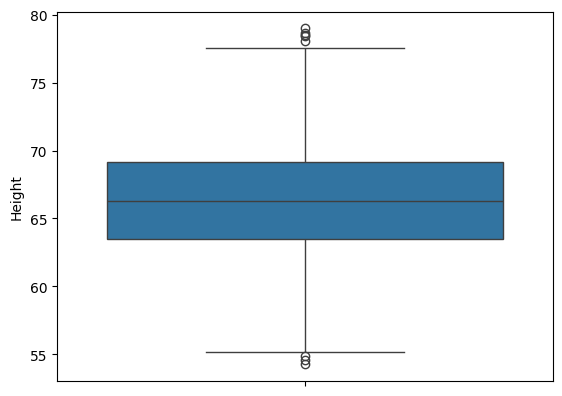

In [12]:
sns.boxplot(df['Height'])

In [ ]:
upper_threshold = df['Height'].quantile(0.99)
upper_threshold

np.float64(74.7857900583366)

In [15]:
lower_threshold = df['Height'].quantile(0.01)
lower_threshold

np.float64(58.13441158671655)

In [24]:
# Outliers

df[(df['Height'] >= upper_threshold) | (df['Height'] < lower_threshold)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


# Trimming

In [28]:
new_df = df[(df['Height'] <= upper_threshold) & (df['Height'] > lower_threshold)]

In [30]:
new_df.shape

(9800, 3)

In [31]:
new_df['Height'].describe()

count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64

C:\Users\admin\AppData\Local\Temp\ipykernel_10972\1622920233.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

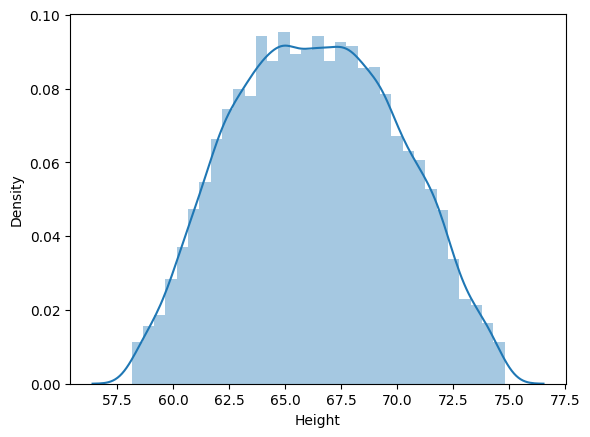

In [32]:
sns.distplot(new_df['Height'])

<Axes: ylabel='Height'>

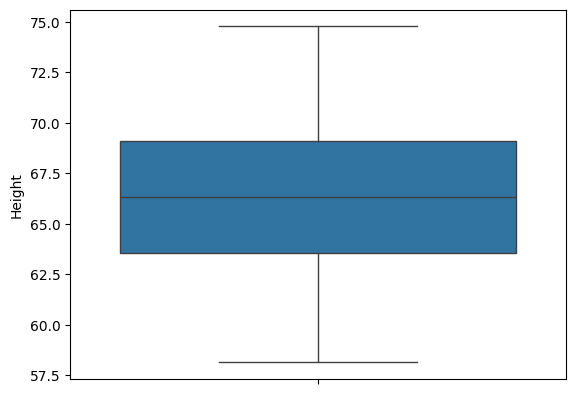

In [33]:
sns.boxplot(new_df['Height'])

# Winsorization

- Replacing the outliers with threshold value is called Winsorization.

In [34]:
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [39]:
# Upeer Threshold with percentile 98
upper_limit = df['Height'].quantile(0.98)
upper_limit

np.float64(73.98591718768152)

In [41]:
# Lower Threshold with percentile 2
lower_limit = df['Height'].quantile(0.02)
lower_limit

np.float64(58.95993803762639)

In [45]:
df['Height'] = np.where(
    df['Height'] >= upper_limit,
    upper_limit,
    np.where(
        df['Height'] <= lower_limit,
        lower_limit,
        df['Height']
    )
)

C:\Users\admin\AppData\Local\Temp\ipykernel_10972\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

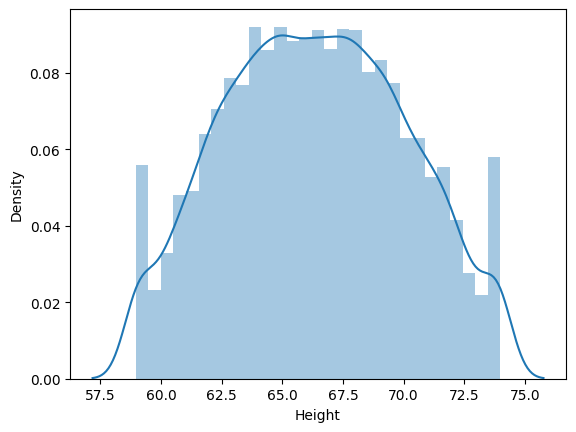

In [47]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

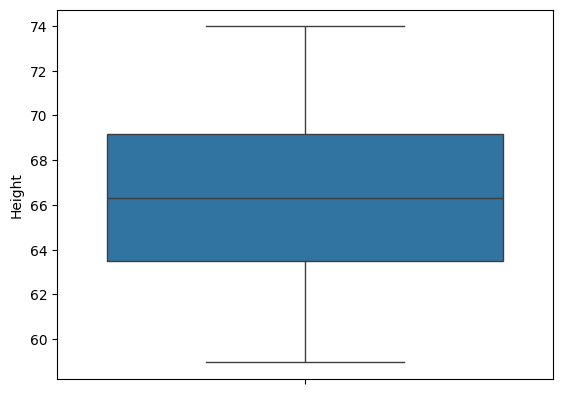

In [48]:
sns.boxplot(df["Height"])

In [49]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.366899,161.440357
std,3.746537,32.108439
min,58.959938,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,73.985917,269.989699
